# Phase 2: GPU-Accelerated Dual Detection Ensemble

**Objective**: Demonstrate the full Phase 2 pipeline:
1. YOLOv8 + Vision Transformer (Worker 1)
2. Faster R-CNN + RT-DETR Lite (Worker 2)
3. Consensus voting (IoU-based matching)
4. Temporal persistence filtering (3-second window)
5. ROI validation
6. Real-time alert generation

**Setup**: Synthetic test video with simulated objects, GPU acceleration (CUDA), mixed precision (FP16)

## 1. Environment Setup & GPU Verification

In [1]:
import os
import sys
import logging
import time
import json
from pathlib import Path

import numpy as np
import cv2
import torch
from redis import Redis
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import matplotlib.patches as mpatches

# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s'
)
logger = logging.getLogger(__name__)

# Add project root to path
project_root = Path('.').resolve()
sys.path.insert(0, str(project_root))

logger.info(f"Project root: {project_root}")
logger.info(f"Python: {sys.version}")
logger.info(f"PyTorch: {torch.__version__}")

c:\Users\Operador\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torch\cuda\__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
2026-04-16 13:13:51,452 - __main__ - INFO - Project root: C:\Users\Operador\Desktop\Nico\cola-frames
2026-04-16 13:13:51,453 - __main__ - INFO - Python: 3.14.3 (tags/v3.14.3:323c59a, Feb  3 2026, 16:04:56) [MSC v.1944 64 bit (AMD64)]
2026-04-16 13:13:51,453 - __main__ - INFO - PyTorch: 2.11.0+cu130


In [2]:
# Verify GPU/CUDA
print("\n=== GPU/CUDA Status ===")
print(f"CUDA Available: {torch.cuda.is_available()}")
print(f"CUDA Version: {torch.version.cuda}")

if torch.cuda.is_available():
    print(f"Number of GPUs: {torch.cuda.device_count()}")
    for i in range(torch.cuda.device_count()):
        props = torch.cuda.get_device_properties(i)
        print(f"  GPU {i}: {props.name}")
        print(f"    - Memory: {props.total_memory / 1e9:.1f} GB")
        print(f"    - Compute Capability: {props.major}.{props.minor}")
else:
    print("âš  GPU not available. CPU-only mode will be used.")


=== GPU/CUDA Status ===
CUDA Available: True
CUDA Version: 13.0
Number of GPUs: 1
  GPU 0: NVIDIA GeForce RTX 3060
    - Memory: 12.9 GB
    - Compute Capability: 8.6


## 2. Import Phase 2 Components

In [3]:
# Import config and Phase 1 components
from config.settings import (
    REDIS_HOST, REDIS_PORT, REDIS_DB,
    DEVICE_WORKER_1, DEVICE_WORKER_2,
    TEMPORAL_PERSISTENCE_SECONDS,
    CONSENSUS_IOU_THRESHOLD,
    DETECTION_CONFIDENCE_THRESHOLD,
    MIXED_PRECISION_FP16,
)
from redis_broker.stream_manager import RedisStreamManager
from producer.frame_serializer import FrameSerializer, FrameDeserializer

# Import Phase 2 components
try:
    from workers.yolo_vit_detector import YOLOVitDetector
    from workers.frcnn_rtdetr_detector import FasterRCNNRtdetrDetector
    from rules_engine.detection_store import DetectionStore
    from rules_engine.temporal_filter import TemporalFilter
    from rules_engine.roi_validator import ROIValidator
    from rules_engine.alert_generator import AlertGenerator
    logger.info("âœ“ All Phase 2 components imported successfully")
except ImportError as e:
    logger.error(f"Failed to import Phase 2 components: {e}")
    raise

c:\Users\Operador\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-04-16 13:13:53,098 - workers.frcnn_rtdetr_detector - WARNING - RT-DETR not available, using placeholder
2026-04-16 13:13:53,100 - __main__ - INFO - âœ“ All Phase 2 components imported successfully


In [4]:
# Test Redis connection
try:
    redis_client = Redis(host=REDIS_HOST, port=REDIS_PORT, db=REDIS_DB, decode_responses=False)
    redis_client.ping()
    logger.info(f"âœ“ Connected to Redis at {REDIS_HOST}:{REDIS_PORT}")
except Exception as e:
    logger.error(f"Failed to connect to Redis: {e}")
    raise

stream_manager = RedisStreamManager()
frame_serializer = FrameSerializer()
frame_deserializer = FrameDeserializer()

2026-04-16 13:13:53,111 - __main__ - INFO - âœ“ Connected to Redis at localhost:6379


[INFO] Connected to Redis at localhost:6379


## 3. Create Synthetic Test Video

In [5]:
def create_synthetic_video(output_path: str = "test_video.mp4", num_frames: int = 150, fps: int = 30):
    """
    Create synthetic test video with moving objects.
    
    Objects:
    - Red rectangle moving left-to-right
    - Green circle moving top-to-bottom
    - Blue rectangle in static position
    """
    frame_width, frame_height = 640, 480
    video_writer = cv2.VideoWriter(
        output_path,
        cv2.VideoWriter_fourcc(*'mp4v'),
        fps,
        (frame_width, frame_height)
    )

    for frame_idx in range(num_frames):
        # Create blank frame
        frame = np.zeros((frame_height, frame_width, 3), dtype=np.uint8)
        frame[:, :] = (40, 40, 40)  # Dark gray background

        # Red rectangle (moving left-to-right)
        x1 = int(50 + (frame_idx % num_frames) / num_frames * 400)
        y1 = 100
        x2 = x1 + 80
        y2 = y1 + 100
        cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 0, 255), -1)  # Red

        # Green circle (moving top-to-bottom)
        cx = 150
        cy = int(50 + (frame_idx % num_frames) / num_frames * 350)
        cv2.circle(frame, (cx, cy), 40, (0, 255, 0), -1)  # Green

        # Blue rectangle (static)
        cv2.rectangle(frame, (400, 200), (550, 350), (255, 0, 0), -1)  # Blue

        # Add frame number text
        cv2.putText(
            frame,
            f"Frame {frame_idx+1}/{num_frames}",
            (10, 30),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (255, 255, 255),
            2
        )

        video_writer.write(frame)

    video_writer.release()
    logger.info(f"âœ“ Created synthetic video: {output_path} ({num_frames} frames @ {fps} FPS)")


# Create test video
test_video_path = "phase2_test_video.mp4"
create_synthetic_video(test_video_path, num_frames=150, fps=30)

2026-04-16 13:13:53,427 - __main__ - INFO - âœ“ Created synthetic video: phase2_test_video.mp4 (150 frames @ 30 FPS)


## 4. Initialize Detection Workers (GPU-Accelerated)

In [6]:
# Initialize Worker 1: YOLOv8 + Vision Transformer
logger.info("Initializing Worker 1: YOLOv8 + Vision Transformer...")
try:
    worker1 = YOLOVitDetector(
        device=DEVICE_WORKER_1 if torch.cuda.is_available() else "cpu",
        batch_size=4,
        confidence_threshold=DETECTION_CONFIDENCE_THRESHOLD,
        use_fp16=MIXED_PRECISION_FP16 and torch.cuda.is_available(),
    )
    logger.info(f"âœ“ Worker 1 initialized: {worker1.get_model_info()}")
except Exception as e:
    logger.error(f"Failed to initialize Worker 1: {e}")
    worker1 = None

# Initialize Worker 2: Faster R-CNN + RT-DETR Lite
logger.info("Initializing Worker 2: Faster R-CNN + RT-DETR Lite...")
try:
    worker2 = FasterRCNNRtdetrDetector(
        device=DEVICE_WORKER_2 if torch.cuda.is_available() else "cpu",
        batch_size=4,
        confidence_threshold=DETECTION_CONFIDENCE_THRESHOLD,
        use_fp16=MIXED_PRECISION_FP16 and torch.cuda.is_available(),
    )
    logger.info(f"âœ“ Worker 2 initialized: {worker2.get_model_info()}")
except Exception as e:
    logger.error(f"Failed to initialize Worker 2: {e}")
    worker2 = None

2026-04-16 13:13:53,434 - __main__ - INFO - Initializing Worker 1: YOLOv8 + Vision Transformer...
2026-04-16 13:13:53,435 - workers.base_detector - INFO - Using GPU device: cuda:0 (GPU Memory: 12.9 GB)
2026-04-16 13:13:53,435 - workers.base_detector - INFO - Detector 'yolo_vit' initialized on device: cuda:0 (FP16: True, Batch Size: 4)
2026-04-16 13:13:53,436 - workers.yolo_vit_detector - INFO - Loading YOLOv8 model...
2026-04-16 13:13:53,607 - workers.yolo_vit_detector - INFO - Loading Vision Transformer model...
2026-04-16 13:13:54,262 - timm.models._builder - INFO - Loading pretrained weights from Hugging Face hub (timm/vit_base_patch16_224.augreg2_in21k_ft_in1k)
2026-04-16 13:13:54,741 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/timm/vit_base_patch16_224.augreg2_in21k_ft_in1k/resolve/main/model.safetensors "HTTP/1.1 302 Found"
2026-04-16 13:13:54,742 - huggingface_hub.utils._http - WARNING - Warning: You are sending unauthenticated requests to the HF Hub. Please set a

## 5. Initialize Rules Engine Components

In [7]:
# Initialize detection store
detection_store = DetectionStore()
logger.info("âœ“ Detection store initialized")

# Initialize temporal filter
temporal_filter = TemporalFilter()
logger.info(f"âœ“ Temporal filter initialized (persistence: {TEMPORAL_PERSISTENCE_SECONDS}s)")

# Initialize ROI validator (no restrictions for this demo)
roi_validator = ROIValidator(roi_config={})
logger.info("âœ“ ROI validator initialized")

# Initialize alert generator
alert_generator = AlertGenerator()
logger.info("âœ“ Alert generator initialized")

2026-04-16 13:13:55,291 - __main__ - INFO - âœ“ Detection store initialized
2026-04-16 13:13:55,292 - __main__ - INFO - âœ“ Temporal filter initialized (persistence: 3s)
2026-04-16 13:13:55,293 - rules_engine.roi_validator - INFO - ROI Validator initialized with 0 camera configurations
2026-04-16 13:13:55,294 - __main__ - INFO - âœ“ ROI validator initialized
2026-04-16 13:13:55,295 - __main__ - INFO - âœ“ Alert generator initialized


## 6. Run Detection Pipeline on Test Video

In [8]:
def run_detection_pipeline(video_path: str, max_frames: int = 50):
    """
    Run the complete Phase 2 detection pipeline.
    """
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    results = {
        "frames_processed": 0,
        "worker1_detections": [],
        "worker2_detections": [],
        "consensus_detections": [],
        "alerts_generated": [],
        "timings": [],
        "samples": [],  # Store sample frames with visualizations
    }

    frame_idx = 0
    camera_id = "camera:demo"

    logger.info(f"Starting detection pipeline on {video_path}")
    logger.info(f"Video info: {frame_count} frames, {fps} FPS")

    start_pipeline_time = time.time()

    while cap.isOpened() and frame_idx < max_frames:
        ret, frame = cap.read()
        if not ret:
            break

        frame_start_time = time.time()

        try:
            # Worker 1 detection (YOLOv8 + ViT)
            worker1_det = None
            if worker1 is not None:
                worker1_det = worker1.detect(frame)
                results["worker1_detections"].append(worker1_det)

            # Worker 2 detection (Faster R-CNN + RT-DETR)
            worker2_det = None
            if worker2 is not None:
                worker2_det = worker2.detect(frame)
                results["worker2_detections"].append(worker2_det)

            # Prepare worker detections dictionary
            worker_detections = {}
            if worker1_det is not None:
                worker_detections["yolo_vit"] = [{
                    "boxes": worker1_det["boxes"],
                    "confidences": worker1_det["confidences"],
                    "class_ids": worker1_det["class_ids"],
                }]
            if worker2_det is not None:
                worker_detections["frcnn_rtdetr"] = [{
                    "boxes": worker2_det["boxes"],
                    "confidences": worker2_det["confidences"],
                    "class_ids": worker2_det["class_ids"],
                }]

            # Consensus voting + temporal persistence
            consensus_dets = temporal_filter.process_detections(
                camera_id,
                worker_detections
            )
            results["consensus_detections"].append(consensus_dets)

            # ROI validation
            roi_validated = roi_validator.validate_detections(camera_id, consensus_dets)

            # Alert generation
            alert_ids = alert_generator.generate_alerts(camera_id, roi_validated)
            results["alerts_generated"].extend(alert_ids)

            # Store timing
            frame_time = (time.time() - frame_start_time) * 1000
            results["timings"].append(frame_time)

            # Store sample frame for visualization (every 10 frames)
            if frame_idx % 10 == 0:
                sample_frame_data = {
                    "frame_idx": frame_idx,
                    "frame": frame.copy(),
                    "worker1": worker1_det,
                    "worker2": worker2_det,
                    "consensus": consensus_dets,
                    "alerts": alert_ids,
                }
                results["samples"].append(sample_frame_data)

            if frame_idx % 10 == 0:
                logger.info(
                    f"Frame {frame_idx+1}: "
                    f"W1={worker1_det['num_detections'] if worker1_det else 0} "
                    f"W2={worker2_det['num_detections'] if worker2_det else 0} "
                    f"Consensus={len(consensus_dets)} "
                    f"Alerts={len(alert_ids)} "
                    f"Time={frame_time:.1f}ms"
                )

            frame_idx += 1
            results["frames_processed"] = frame_idx

        except Exception as e:
            logger.error(f"Error processing frame {frame_idx}: {e}")
            continue

    cap.release()

    total_pipeline_time = time.time() - start_pipeline_time
    logger.info(f"\n=== Pipeline Execution Complete ===")
    logger.info(f"Processed: {results['frames_processed']} frames")
    logger.info(f"Total time: {total_pipeline_time:.2f}s")
    logger.info(f"Avg FPS: {results['frames_processed'] / total_pipeline_time:.1f}")
    logger.info(f"Alerts generated: {len(results['alerts_generated'])}")

    return results


# Run pipeline
logger.info("\n" + "="*50)
logger.info("Starting Phase 2 Detection Pipeline")
logger.info("="*50)

pipeline_results = run_detection_pipeline(test_video_path, max_frames=50)

2026-04-16 13:13:55,308 - __main__ - INFO - 
2026-04-16 13:13:55,309 - __main__ - INFO - Starting Phase 2 Detection Pipeline
2026-04-16 13:13:55,309 - __main__ - INFO - ==================================================
2026-04-16 13:13:55,317 - __main__ - INFO - Starting detection pipeline on phase2_test_video.mp4
2026-04-16 13:13:55,318 - __main__ - INFO - Video info: 150 frames, 30.0 FPS
C:\Users\Operador\Desktop\Nico\cola-frames\workers\frcnn_rtdetr_detector.py:191: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=self.use_fp16):
2026-04-16 13:13:56,042 - __main__ - INFO - Frame 1: W1=0 W2=0 Consensus=0 Alerts=0 Time=716.3ms
C:\Users\Operador\Desktop\Nico\cola-frames\workers\yolo_vit_detector.py:206: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=self.use_fp16):
2026-04-16 13:13:56,708 -

## 7. Performance Analysis

In [9]:
# Calculate statistics
timings = pipeline_results["timings"]

print("\n=== Performance Statistics ===")
print(f"Frames processed: {pipeline_results['frames_processed']}")
print(f"\nExecution Time (ms):")
print(f"  - Min: {min(timings):.1f}")
print(f"  - Max: {max(timings):.1f}")
print(f"  - Mean: {np.mean(timings):.1f}")
print(f"  - Std: {np.std(timings):.1f}")
print(f"\nFPS: {1000 / np.mean(timings):.1f} (average)")

print(f"\nDetection Statistics:")
w1_count = sum(d["num_detections"] for d in pipeline_results["worker1_detections"] if d)
w2_count = sum(d["num_detections"] for d in pipeline_results["worker2_detections"] if d)
consensus_count = sum(len(d) for d in pipeline_results["consensus_detections"])
print(f"  - Worker 1 total detections: {w1_count}")
print(f"  - Worker 2 total detections: {w2_count}")
print(f"  - Consensus detections: {consensus_count}")
print(f"  - Alerts generated: {len(pipeline_results['alerts_generated'])}")

if w1_count > 0 and consensus_count > 0:
    agreement_rate = (consensus_count / max(w1_count, w2_count)) * 100
    print(f"  - Consensus agreement rate: {agreement_rate:.1f}%")


=== Performance Statistics ===
Frames processed: 50

Execution Time (ms):
  - Min: 69.0
  - Max: 716.3
  - Mean: 87.2
  - Std: 90.1

FPS: 11.5 (average)

Detection Statistics:
  - Worker 1 total detections: 17
  - Worker 2 total detections: 50
  - Consensus detections: 5
  - Alerts generated: 5
  - Consensus agreement rate: 10.0%


## 8. Visualization: Detection Comparison

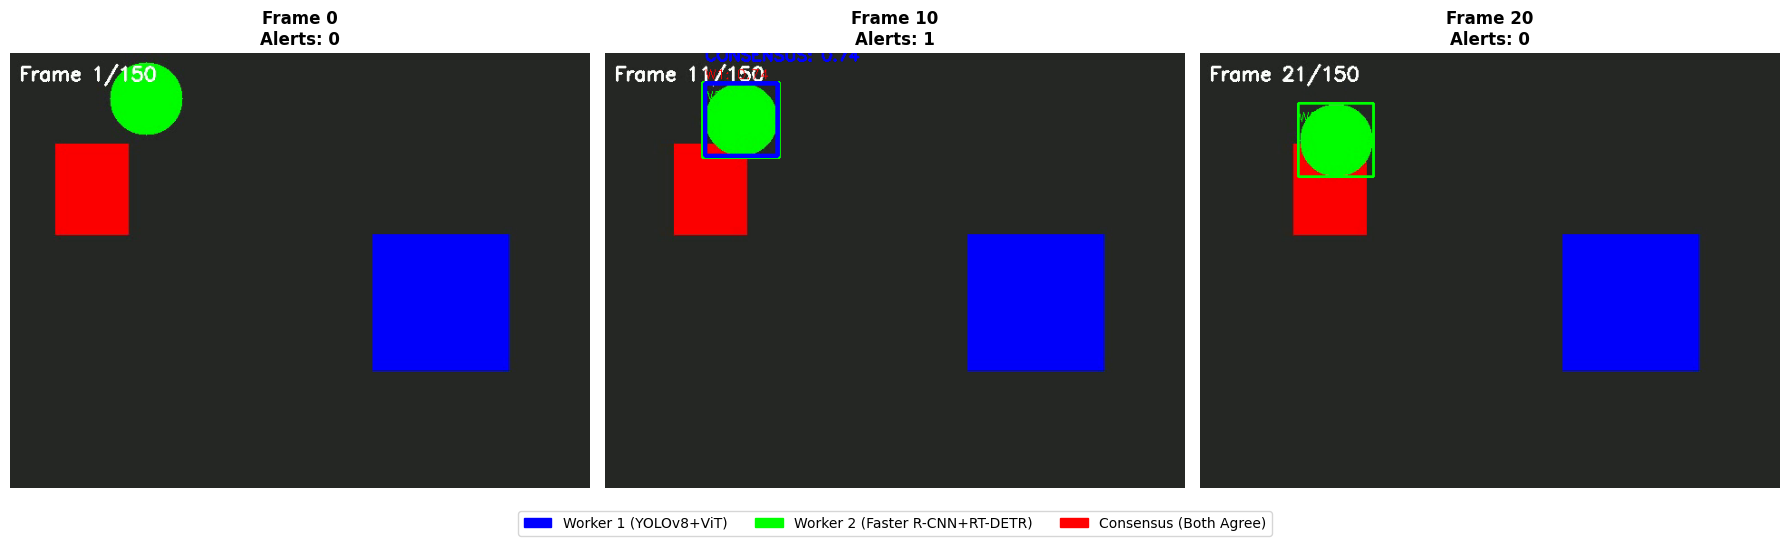

In [10]:
def visualize_detections(frame, worker1_det, worker2_det, consensus_dets, title=""):
    """
    Visualize detections from both workers and consensus.
    
    Colors:
    - Red: Worker 1 (YOLOv8+ViT)
    - Green: Worker 2 (Faster R-CNN+RT-DETR)
    - Blue: Consensus (both workers agree)
    """
    viz_frame = frame.copy()

    # Worker 1 detections (Red)
    if worker1_det and len(worker1_det["boxes"]) > 0:
        boxes = np.atleast_1d(np.asarray(worker1_det["boxes"]))
        confs = np.atleast_1d(np.asarray(worker1_det["confidences"]))
        for box, conf in zip(boxes, confs):
            x1, y1, x2, y2 = map(int, box)
            cv2.rectangle(viz_frame, (x1, y1), (x2, y2), (0, 0, 255), 2)  # Red
            cv2.putText(
                viz_frame,
                f"W1: {float(conf):.2f}",
                (x1, y1 - 5),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                (0, 0, 255),
                1,
            )

    # Worker 2 detections (Green)
    if worker2_det and len(worker2_det["boxes"]) > 0:
        boxes = np.atleast_1d(np.asarray(worker2_det["boxes"]))
        confs = np.atleast_1d(np.asarray(worker2_det["confidences"]))
        for box, conf in zip(boxes, confs):
            x1, y1, x2, y2 = map(int, box)
            cv2.rectangle(viz_frame, (x1, y1), (x2, y2), (0, 255, 0), 2)  # Green
            cv2.putText(
                viz_frame,
                f"W2: {float(conf):.2f}",
                (x1, y1 + 20),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                (0, 255, 0),
                1,
            )

    # Consensus detections (Blue with thicker box)
    if consensus_dets and len(consensus_dets) > 0:
        for det in consensus_dets:
            boxes = np.atleast_1d(np.asarray(det["boxes"]))
            confs = np.atleast_1d(np.asarray(det["confidences"]))
            for box, conf in zip(boxes, confs):
                x1, y1, x2, y2 = map(int, box)
                cv2.rectangle(viz_frame, (x1, y1), (x2, y2), (255, 0, 0), 3)  # Blue, thick
                cv2.putText(
                    viz_frame,
                    f"CONSENSUS: {float(conf):.2f}",
                    (x1, y1 - 25),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.6,
                    (255, 0, 0),
                    2,
                )

    return viz_frame


# Visualize samples
if pipeline_results["samples"]:
    num_samples = min(3, len(pipeline_results["samples"]))
    fig, axes = plt.subplots(1, num_samples, figsize=(18, 5))

    for idx, sample in enumerate(pipeline_results["samples"][:num_samples]):
        viz_frame = visualize_detections(
            sample["frame"],
            sample["worker1"],
            sample["worker2"],
            sample["consensus"],
            title=f"Frame {sample['frame_idx']}"
        )

        # Convert BGR to RGB for display
        viz_frame_rgb = cv2.cvtColor(viz_frame, cv2.COLOR_BGR2RGB)
        axes[idx].imshow(viz_frame_rgb)
        axes[idx].set_title(
            f"Frame {sample['frame_idx']}\n"
            f"Alerts: {len(sample['alerts'])}",
            fontsize=12,
            fontweight="bold",
        )
        axes[idx].axis("off")

    # Legend
    red_patch = mpatches.Patch(color=(0, 0, 1), label='Worker 1 (YOLOv8+ViT)')
    green_patch = mpatches.Patch(color=(0, 1, 0), label='Worker 2 (Faster R-CNN+RT-DETR)')
    blue_patch = mpatches.Patch(color=(1, 0, 0), label='Consensus (Both Agree)')
    fig.legend(
        handles=[red_patch, green_patch, blue_patch],
        loc="lower center",
        ncol=3,
        bbox_to_anchor=(0.5, -0.05),
    )

    plt.tight_layout()
    plt.show()
else:
    print("No samples available for visualization.")

## 9. Performance Timing Chart

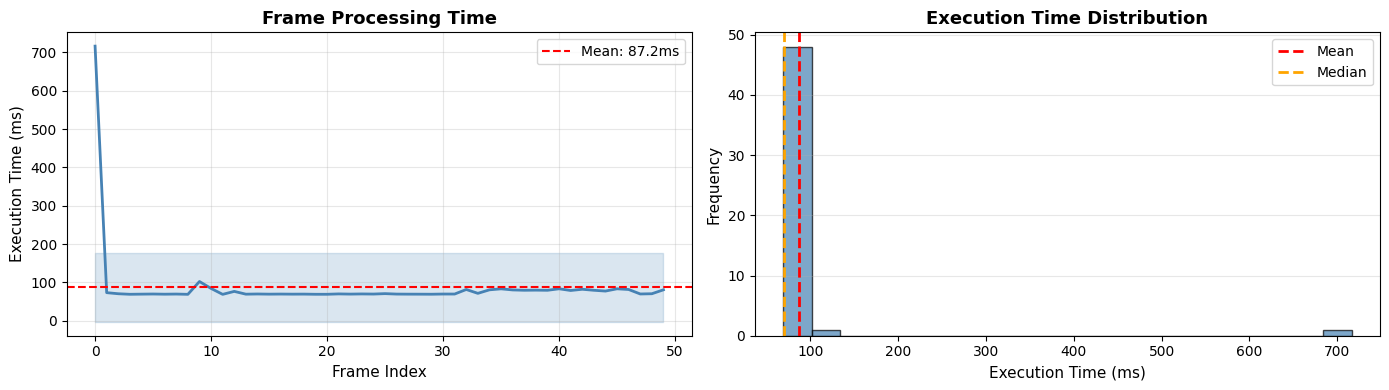


Average FPS: 11.5


In [11]:
# Plot execution time per frame
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Line plot: execution time per frame
ax1.plot(pipeline_results["timings"], linewidth=2, color="steelblue")
ax1.axhline(y=np.mean(pipeline_results["timings"]), color="red", linestyle="--", label=f"Mean: {np.mean(pipeline_results['timings']):.1f}ms")
ax1.fill_between(
    range(len(pipeline_results["timings"])),
    np.mean(pipeline_results["timings"]) - np.std(pipeline_results["timings"]),
    np.mean(pipeline_results["timings"]) + np.std(pipeline_results["timings"]),
    alpha=0.2,
    color="steelblue",
)
ax1.set_xlabel("Frame Index", fontsize=11)
ax1.set_ylabel("Execution Time (ms)", fontsize=11)
ax1.set_title("Frame Processing Time", fontsize=13, fontweight="bold")
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=10)

# Histogram: execution time distribution
ax2.hist(pipeline_results["timings"], bins=20, color="steelblue", edgecolor="black", alpha=0.7)
ax2.axvline(x=np.mean(pipeline_results["timings"]), color="red", linestyle="--", linewidth=2, label="Mean")
ax2.axvline(x=np.median(pipeline_results["timings"]), color="orange", linestyle="--", linewidth=2, label="Median")
ax2.set_xlabel("Execution Time (ms)", fontsize=11)
ax2.set_ylabel("Frequency", fontsize=11)
ax2.set_title("Execution Time Distribution", fontsize=13, fontweight="bold")
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

print(f"\nAverage FPS: {1000 / np.mean(pipeline_results['timings']):.1f}")

## 10. Alert Statistics & Summary

In [12]:
# Get alert statistics
alert_stats = alert_generator.get_alert_stats(camera_id="camera:demo")

print("\n=== Alert Summary ===")
print(f"Total alerts generated: {alert_stats.get('total_alerts', 0)}")
print(f"Active (unacknowledged): {alert_stats.get('active_alerts', 0)}")
print(f"High severity: {alert_stats.get('high_severity', 0)}")
print(f"Medium severity: {alert_stats.get('medium_severity', 0)}")
print(f"Low severity: {alert_stats.get('low_severity', 0)}")

# Get sample alerts
sample_alerts = alert_generator.get_active_alerts(camera_id="camera:demo", limit=5)
print(f"\n=== Recent Alerts (Latest 5) ===")
for alert in sample_alerts[:5]:
    print(f"  - Alert ID: {alert.get('alert_id', 'N/A')}")
    print(f"    Timestamp: {alert.get('timestamp', 'N/A')}")
    print(f"    Detections: {alert.get('num_detections', 0)}")
    print(f"    Avg Confidence: {alert.get('avg_confidence', 0):.2f}")
    print(f"    Severity: {alert.get('severity', 'N/A')}")
    print(f"    Workers Agreed: {alert.get('workers_count', 0)}")
    print()


=== Alert Summary ===
Total alerts generated: 14
Active (unacknowledged): 14
High severity: 0
Medium severity: 0
Low severity: 14

=== Recent Alerts (Latest 5) ===
  - Alert ID: N/A
    Timestamp: 1776359640.0865245
    Detections: 0
    Avg Confidence: 0.00
    Severity: N/A
    Workers Agreed: 0

  - Alert ID: N/A
    Timestamp: 1776359640.0865214
    Detections: 0
    Avg Confidence: 0.00
    Severity: N/A
    Workers Agreed: 0

  - Alert ID: N/A
    Timestamp: 1776359640.0865178
    Detections: 0
    Avg Confidence: 0.00
    Severity: N/A
    Workers Agreed: 0

  - Alert ID: N/A
    Timestamp: 1776359640.0865135
    Detections: 0
    Avg Confidence: 0.00
    Severity: N/A
    Workers Agreed: 0

  - Alert ID: N/A
    Timestamp: 1776359640.0865014
    Detections: 0
    Avg Confidence: 0.00
    Severity: N/A
    Workers Agreed: 0



## 11. Cleanup & GPU Memory

In [13]:
# Clean up workers
logger.info("Cleaning up GPU memory and resources...")
if worker1 is not None:
    worker1.cleanup()
if worker2 is not None:
    worker2.cleanup()

# Clear Redis streams (optional)
try:
    redis_client.delete("detections:yolo_vit:camera:demo")
    redis_client.delete("detections:frcnn_rtdetr:camera:demo")
    redis_client.delete("alerts:camera:demo")
    logger.info("âœ“ Cleared Redis detection and alert streams")
except Exception as e:
    logger.warning(f"Failed to clear Redis streams: {e}")

logger.info("\n=== Phase 2 Demo Complete ===")
logger.info(f"Summary: Processed {pipeline_results['frames_processed']} frames with dual ensemble detection")
logger.info(f"Average FPS: {1000 / np.mean(pipeline_results['timings']):.1f}")
logger.info(f"Consensus detections: {sum(len(d) for d in pipeline_results['consensus_detections'])}")
logger.info(f"Alerts generated: {len(pipeline_results['alerts_generated'])}")

2026-04-16 13:14:00,093 - __main__ - INFO - Cleaning up GPU memory and resources...
2026-04-16 13:14:00,097 - workers.base_detector - INFO - Detector 'yolo_vit' cleaned up
2026-04-16 13:14:00,098 - workers.base_detector - INFO - Detector 'frcnn_rtdetr' cleaned up
2026-04-16 13:14:00,100 - __main__ - INFO - âœ“ Cleared Redis detection and alert streams
2026-04-16 13:14:00,101 - __main__ - INFO - 
=== Phase 2 Demo Complete ===
2026-04-16 13:14:00,101 - __main__ - INFO - Summary: Processed 50 frames with dual ensemble detection
2026-04-16 13:14:00,102 - __main__ - INFO - Average FPS: 11.5
2026-04-16 13:14:00,102 - __main__ - INFO - Consensus detections: 5
2026-04-16 13:14:00,103 - __main__ - INFO - Alerts generated: 5
